# Project 100 – Fatal Force in the United States

This project analyzes fatal police shootings in the United States using data compiled by The Washington Post since 2015.

The dataset is combined with U.S. Census data including:

• Poverty rates  
• High school graduation rates  
• Median household income  
• Racial demographics  

The goal of this analysis is to explore possible **social patterns and correlations** related to fatal police shootings.

This project focuses on **data exploration and statistical patterns**, not causal conclusions.

Datasets used:

1. Washington Post Fatal Police Shootings
2. US Census Poverty Rates
3. US Census High School Graduation Rates
4. US Median Household Income
5. Racial Demographics by City

---

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_palette("deep")

## Loading the datasets

In [2]:
fatal_force = pd.read_csv("../data/Deaths_by_Police_US.csv", encoding="latin-1")

income = pd.read_csv("../data/Median_Household_Income_2015.csv", encoding="latin-1")
poverty = pd.read_csv("../data/Pct_People_Below_Poverty_Level.csv", encoding="latin-1")
education = pd.read_csv("../data/Pct_Over_25_Completed_High_School.csv", encoding="latin-1")
race = pd.read_csv("../data/Share_of_Race_By_City.csv", encoding="latin-1")

## Exploring the Fatal Police Shootings dataset

In [3]:
fatal_force.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,02/01/15,shot,gun,53.0,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.0,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.0,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.0,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.0,M,H,Evans,CO,False,attack,Not fleeing,False


In [4]:
fatal_force.info()

<class 'pandas.DataFrame'>
RangeIndex: 2535 entries, 0 to 2534
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       2535 non-null   int64  
 1   name                     2535 non-null   str    
 2   date                     2535 non-null   str    
 3   manner_of_death          2535 non-null   str    
 4   armed                    2526 non-null   str    
 5   age                      2458 non-null   float64
 6   gender                   2535 non-null   str    
 7   race                     2340 non-null   str    
 8   city                     2535 non-null   str    
 9   state                    2535 non-null   str    
 10  signs_of_mental_illness  2535 non-null   bool   
 11  threat_level             2535 non-null   str    
 12  flee                     2470 non-null   str    
 13  body_camera              2535 non-null   bool   
dtypes: bool(2), float64(1), int64(1), s

In [5]:
fatal_force.describe()

,id,age
count,2535.000000,2458.000000
mean,1445.731755,36.605370
std,794.259490,13.030774
min,3.000000,6.000000
25%,768.500000,26.000000
50%,1453.000000,34.000000
75%,2126.500000,45.000000
max,2822.000000,91.000000


---
## Cleaning the Fatal Force Dataset

I clean missing values and convert fields to proper types.

In [6]:
fatal_force["date"] = pd.to_datetime(fatal_force["date"])

fatal_force["age"] = pd.to_numeric(fatal_force["age"], errors="coerce")

fatal_force["race"].fillna("Unknown", inplace=True)
fatal_force["armed"].fillna("Unknown", inplace=True)

/tmp/ipykernel_306493/2936072163.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  fatal_force["date"] = pd.to_datetime(fatal_force["date"])
/tmp/ipykernel_306493/2936072163.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable

0              gun
1              gun
2          unarmed
3       toy weapon
4         nail gun
           ...    
2530           gun
2531       vehicle
2532           gun
2533       vehicle
2534         knife
Name: armed, Length: 2535, dtype: str

In [7]:
fatal_force.isna().sum()

id                           0
name                         0
date                         0
manner_of_death              0
armed                        9
age                         77
gender                       0
race                       195
city                         0
state                        0
signs_of_mental_illness      0
threat_level                 0
flee                        65
body_camera                  0
dtype: int64

---
## Fatal police shootings over time

In [8]:
fatal_force["year"] = fatal_force["date"].dt.year

shootings_per_year = fatal_force.groupby("year").size()

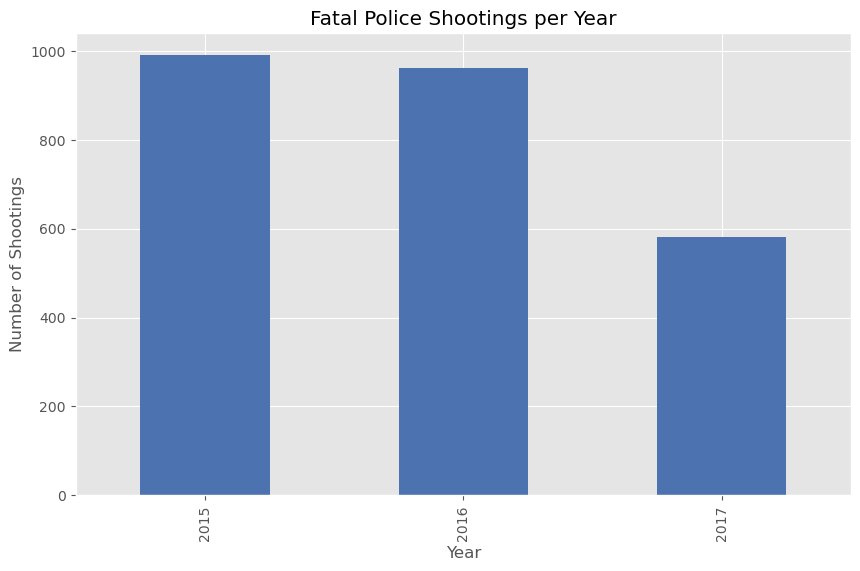

In [9]:
plt.figure(figsize=(10,6))

shootings_per_year.plot(kind="bar")

plt.title("Fatal Police Shootings per Year")
plt.xlabel("Year")
plt.ylabel("Number of Shootings")

plt.show()

---
## Age distribution

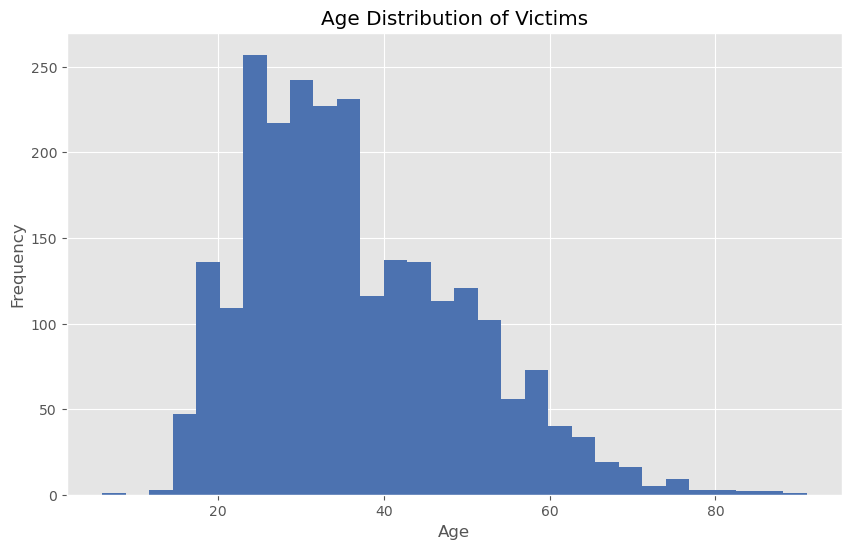

In [10]:
plt.figure(figsize=(10,6))

fatal_force["age"].hist(bins=30)

plt.title("Age Distribution of Victims")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

---
## Race of victims

In [11]:
race_counts = fatal_force["race"].value_counts()

race_counts

race
W    1201
B     618
H     423
A      39
N      31
O      28
Name: count, dtype: int64

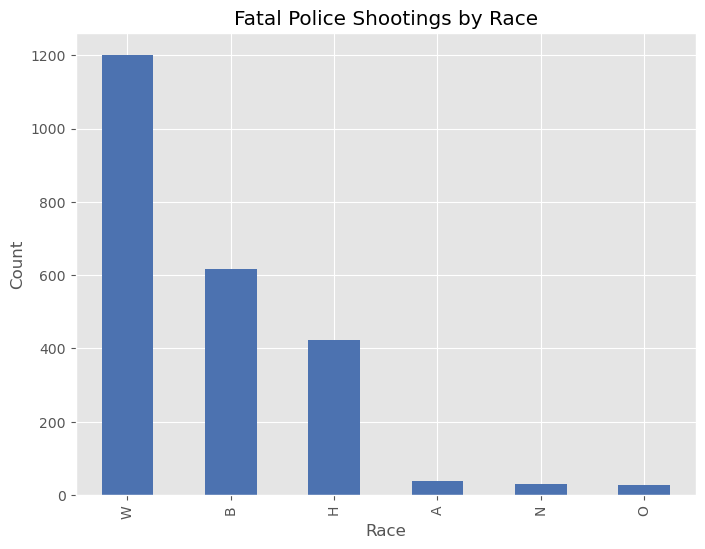

In [12]:
plt.figure(figsize=(8,6))

race_counts.plot(kind="bar")

plt.title("Fatal Police Shootings by Race")
plt.xlabel("Race")
plt.ylabel("Count")

plt.show()

---
## Gender Distribution

In [13]:
fatal_force["gender"].value_counts()

gender
M    2428
F     107
Name: count, dtype: int64

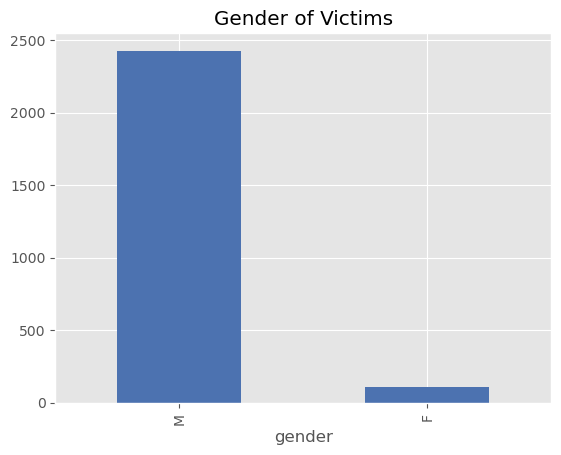

In [14]:
fatal_force["gender"].value_counts().plot(kind="bar")

plt.title("Gender of Victims")
plt.show()

---
## Armed vs Unarmed

Understanding whether victims were armed.

In [15]:
fatal_force["armed"].value_counts().head(10)

armed
gun               1398
knife              373
vehicle            177
unarmed            171
undetermined       117
toy weapon         104
machete             18
unknown weapon      18
Taser                9
ax                   9
Name: count, dtype: int64

---
## Mental Illness Indicator

In [16]:
fatal_force["signs_of_mental_illness"].value_counts()

signs_of_mental_illness
False    1902
True      633
Name: count, dtype: int64

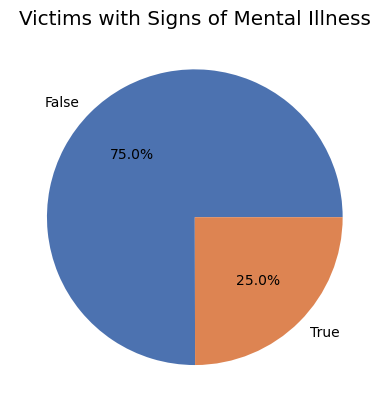

In [17]:
fatal_force["signs_of_mental_illness"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Victims with Signs of Mental Illness")

plt.show()

---
## Shootings by State

In [18]:
state_counts = fatal_force["state"].value_counts().head(10)

state_counts

state
CA    424
TX    225
FL    154
AZ    118
OH     79
OK     78
CO     74
GA     70
NC     69
MO     64
Name: count, dtype: int64

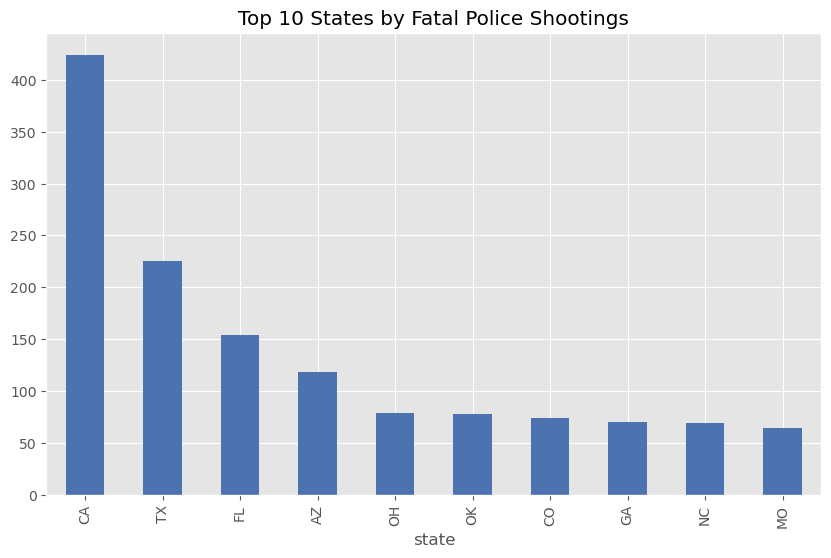

In [19]:
plt.figure(figsize=(10,6))

state_counts.plot(kind="bar")

plt.title("Top 10 States by Fatal Police Shootings")

plt.show()

---
## Preparing Census Data



Before merging census data I need to clean the city names.

In [20]:
income.rename(columns={"Geographic Area":"state"}, inplace=True)
poverty.rename(columns={"Geographic Area":"state"}, inplace=True)
education.rename(columns={"Geographic Area":"state"}, inplace=True)
race.rename(columns={"Geographic area":"state"}, inplace=True)

### Poverty Rate Analysis

In [21]:
poverty["poverty_rate"] = pd.to_numeric(poverty["poverty_rate"], errors="coerce")

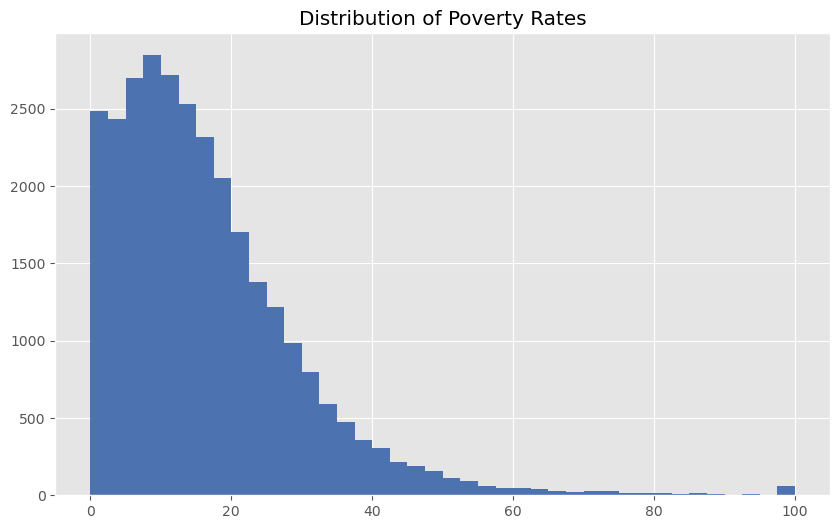

In [22]:
plt.figure(figsize=(10,6))

poverty["poverty_rate"].hist(bins=40)

plt.title("Distribution of Poverty Rates")

plt.show()

### Median Household Income

In [23]:
income["Median Income"] = pd.to_numeric(income["Median Income"], errors="coerce")

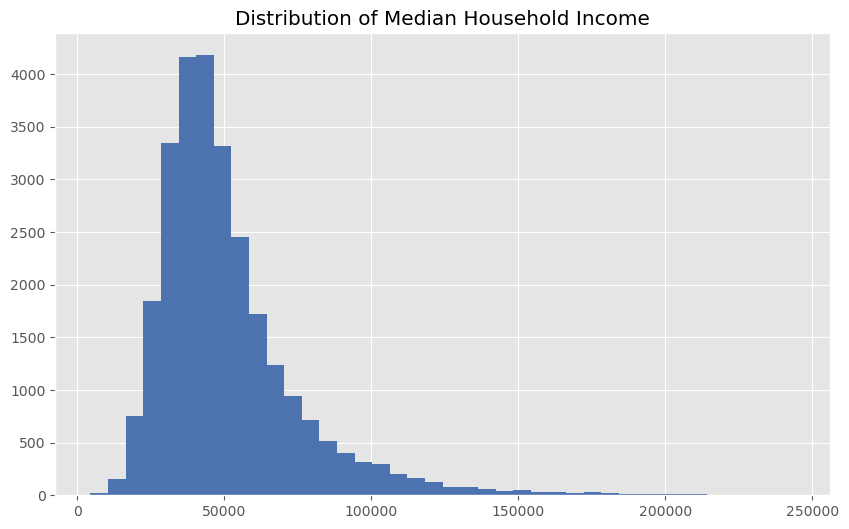

In [24]:
plt.figure(figsize=(10,6))

income["Median Income"].hist(bins=40)

plt.title("Distribution of Median Household Income")

plt.show()

### High School Graduation Rate

In [25]:
education["percent_completed_hs"] = pd.to_numeric(
    education["percent_completed_hs"],
    errors="coerce"
)

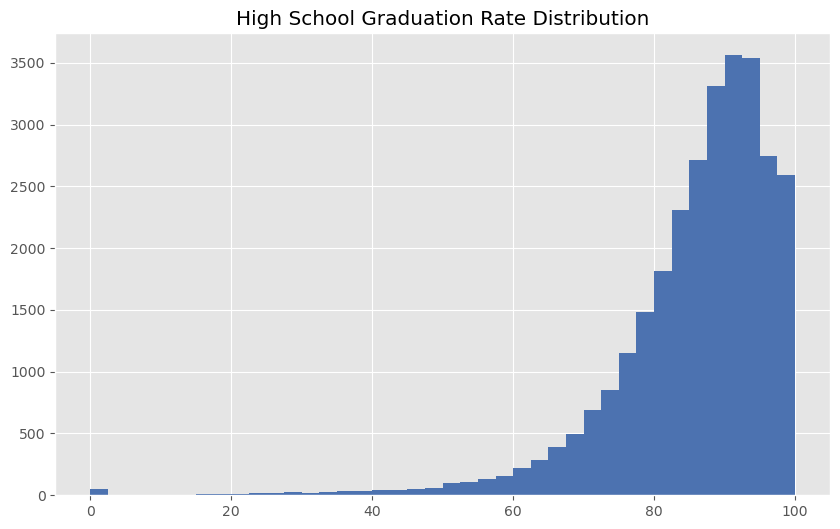

In [26]:
plt.figure(figsize=(10,6))

education["percent_completed_hs"].hist(bins=40)

plt.title("High School Graduation Rate Distribution")

plt.show()

### Racial Demographics

In [27]:
race.head()

,state,City,share_white,share_black,share_native_american,share_asian,share_hispanic
0,AL,Abanda CDP,67.2,30.2,0,0,1.6
1,AL,Abbeville city,54.4,41.4,0.1,1,3.1
2,AL,Adamsville city,52.3,44.9,0.5,0.3,2.3
3,AL,Addison town,99.1,0.1,0,0.1,0.4
4,AL,Akron town,13.2,86.5,0,0,0.3


In [28]:
race.describe()

,state,City,share_white,share_black,share_native_american,share_asian,share_hispanic
count,29268,29268,29268,29268,29268,29268,29268
unique,51,24219,997,926,628,409,956
top,PA,Franklin city,100,0,0,0,0
freq,1764,16,1051,6587,6930,8537,2489


---
## Correlation Analysis

Analyzing relationships between socioeconomic factors.

In [29]:
combined = pd.merge(income, poverty, on=["City","state"], how="inner")
combined = pd.merge(combined, education, on=["City","state"], how="inner")

In [30]:
combined.head()

,state,City,Median Income,poverty_rate,percent_completed_hs
0,AL,Abanda CDP,11207.0,78.8,21.2
1,AL,Abbeville city,25615.0,29.1,69.1
2,AL,Adamsville city,42575.0,25.5,78.9
3,AL,Addison town,37083.0,30.7,81.4
4,AL,Akron town,21667.0,42.0,68.6


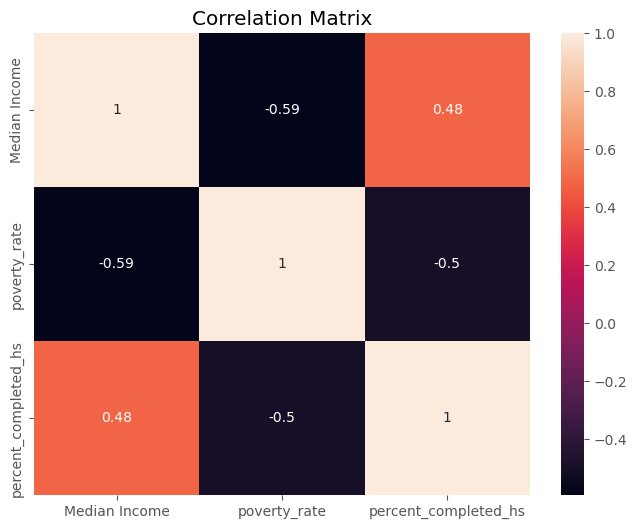

In [31]:
corr = combined.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True)

plt.title("Correlation Matrix")

plt.show()

Key patterns observed:

• Most victims are male  
• Victim ages cluster around young to middle adulthood  
• Certain states show significantly higher incident counts  
• Socioeconomic variables such as poverty and income show interesting correlations  

Important note:

Correlation does **not imply causation**, and multiple social, legal, and institutional factors influence these outcomes.

---

## Final Conclusion

This analysis explored fatal police shootings alongside socioeconomic data from the US Census.

The project demonstrates:

• Data cleaning
• Exploratory analysis
• Visualization
• Dataset merging
• Correlation analysis

Future work could include:

• Normalizing shootings per population
• Time-series analysis
• County-level analysis
• Predictive modeling